Q1. Read and explore the given dataset.  ( Rename column/add headers, plot histograms, find data characteristics)

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
!pip install turicreate

In [0]:
import time
import turicreate as tc
from sklearn.model_selection import train_test_split
import sys
sys.path.append("..")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
ratings  = pd.read_csv('/content/drive/My Drive/R6/ratings_Electronics.csv',  names=['UserID', 'ProductID', 'Ratings',  'TimeStamp']) 

In [6]:
ratings.head()

,UserID,ProductID,Ratings,TimeStamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [0]:
ratings = ratings.drop(['TimeStamp'], axis=1)

In [8]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
UserID       object
ProductID    object
Ratings      float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB


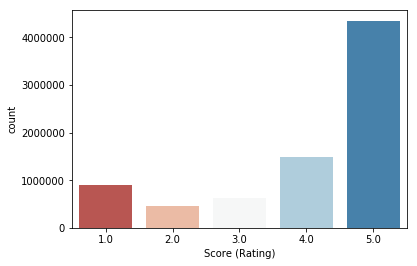

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.countplot(x='Ratings', data=ratings, palette='RdBu')
plt.xlabel('Score (Rating)')
plt.show()

In [10]:
ratings.Ratings.value_counts()

5.0    4347541
4.0    1485781
1.0     901765
3.0     633073
2.0     456322
Name: Ratings, dtype: int64

Q2. Take a subset of the dataset to make it less sparse/ denser. 
( For example, keep the users only who has given 50 or more number of ratings )

In [11]:
x = ratings.UserID.value_counts()
x.to_dict()
print("converted Series to dictionary")

converted Series to dictionary


In [0]:
ratings["reviewer_freq"] = ratings["UserID"].apply(lambda counts: "Frequent (>50 reviews)" \
                                                                 if x[counts]>50 else "Not Frequent (1-50)")

In [13]:
ratings.head()

,UserID,ProductID,Ratings,reviewer_freq
0,AKM1MP6P0OYPR,0132793040,5.0,Not Frequent (1-50)
1,A2CX7LUOHB2NDG,0321732944,5.0,Not Frequent (1-50)
2,A2NWSAGRHCP8N5,0439886341,1.0,Not Frequent (1-50)
3,A2WNBOD3WNDNKT,0439886341,3.0,Not Frequent (1-50)
4,A1GI0U4ZRJA8WN,0439886341,1.0,Not Frequent (1-50)


In [0]:
df = ratings[ratings.reviewer_freq=="Frequent (>50 reviews)"]

In [0]:
df= df.drop(['reviewer_freq'], axis=1)

In [16]:
df.shape

(122171, 3)

In [17]:
transcation = df.pivot(index = 'UserID', columns ='ProductID', values = 'Ratings').fillna(0) ## replacing all NaN with 0
transcation.head()

ProductID,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,1400698987,1400699169,1685560148,3744295508,7562434166,787988002X,8862935307,8862936826,9043413585,9573212900,9573212919,9575871979,9800359788,9981719005,9981734241,9981739588,9983722615,998376234X,9983891212,9984922626,9985511298,9985525264,9985696999,9989360391,B000000O48,B000001OKH,B000001OL6,B000001OM4,B000001OM5,B000001OMI,...,B00KSBB84S,B00KSTODWY,B00KT17TZ4,B00KTIYN7O,B00KU4RD4M,B00KVLY8E2,B00KVNY2KA,B00KW2W6B2,B00KW3OFG0,B00KWHMR6G,B00KWL62QI,B00KWMNDDM,B00KWPRSJY,B00KWWY1PQ,B00KXAFYZS,B00KXMN08E,B00KXUHX9S,B00KYA7CT8,B00KYMCJF8,B00L0YFJHY,B00L1I727Y,B00L1I80K2,B00L1NZTSS,B00L21HC7A,B00L2442H0,B00L26YDA4,B00L2P3TRS,B00L3YHF6O,B00L403O94,B00L43HAY6,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
UserID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Q3. Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)

In [0]:
#define a splitting function below
def split_data(df):
    train, test = train_test_split(df, test_size = .3)
    train_data = tc.SFrame(train)
    test_data = tc.SFrame(test)
    return train_data, test_data

In [0]:
train_data, test_data = split_data(df)


Q4. Build Popularity Recommender model.

In [0]:

# variables to define field names
user_id = 'UserID'
item_id = 'ProductID'
rating = 'Ratings'
users_to_recommend = list(df[user_id])
n_rec = 10 # number of items to recommend
n_display = 30

In [21]:
rating

'Ratings'

In [22]:

popularity_model = tc.popularity_recommender.create(train_data, user_id=user_id,item_id=item_id,target=rating )

Preparing data set.

Data has 85519 observations with 1466 users and 37351 items.

Data prepared in: 0.127226s

85519 observations to process; with 37351 unique items.

In [23]:
# Get recommendations for a list of users to recommend (from customers file)
# Printed below is head / top 30 rows for first 3 customers with 10 recommendations each

popularity_recomm = popularity_model.recommend(users=users_to_recommend, k=n_rec)
popularity_recomm.print_rows(n_display)

recommendations finished on 1000/122171 queries. users per second: 4661.33

recommendations finished on 2000/122171 queries. users per second: 4763.88

recommendations finished on 3000/122171 queries. users per second: 4794.39

recommendations finished on 4000/122171 queries. users per second: 4817.79

recommendations finished on 5000/122171 queries. users per second: 4727.93

...

recommendations finished on 119000/122171 queries. users per second: 4770.62

recommendations finished on 120000/122171 queries. users per second: 4771.72

recommendations finished on 121000/122171 queries. users per second: 4772.04

recommendations finished on 122000/122171 queries. users per second: 4767.31

+----------------+------------+-------+------+
|     UserID     | ProductID  | score | rank |
+----------------+------------+-------+------+
| AT09WGFUM934H  | B00006G33O |  5.0  |  1   |
| AT09WGFUM934H  | B0001WOSJG |  5.0  |  2   |
| AT09WGFUM934H  | B001K9BEIW |  5.0  |  3   |
| AT09WGFUM934H  | B001SEB45M |  5.0  |  4   |
| AT09WGFUM934H  | B007YV0UQW |  5.0  |  5   |
| AT09WGFUM934H  | B00005T3CF |  5.0  |  6   |
| AT09WGFUM934H  | B003ZUXVR6 |  5.0  |  7   |
| AT09WGFUM934H  | B0002KRCH2 |  5.0  |  8   |
| AT09WGFUM934H  | B004T163SY |  5.0  |  9   |
| AT09WGFUM934H  | B000J31N1S |  5.0  |  10  |
| A32HSNCNPRUMTR | B00006G33O |  5.0  |  1   |
| A32HSNCNPRUMTR | B0001WOSJG |  5.0  |  2   |
| A32HSNCNPRUMTR | B001K9BEIW |  5.0  |  3   |
| A32HSNCNPRUMTR | B001SEB45M |  5.0  |  4   |
| A32HSNCNPRUMTR | B007YV0UQW |  5.0  |  5   |
| A32HSNCNPRUMTR | B00005T3CF |  5.0  |  6   |
| A32HSNCNPRUMTR | B003ZUXVR6 |  5.0  |  7   |
| A32HSNCNPRUMTR | B0002KRCH2 |  5.0  |  8   |
| A32HSNCNPRU

Q5. Build Collaborative Filtering model.

In [0]:
Method 1 : Cosine similarity
  Similarity is the cosine of the angle between the 2 vectors of the item vectors of A and B

In [0]:
def model(train_data, name, user_id, item_id, target, users_to_recommend, n_rec, n_display):
    if name == 'popularity':
        model = tc.popularity_recommender.create(train_data, 
                                                    user_id=user_id, 
                                                    item_id=item_id, 
                                                    target=rating)
    elif name == 'cosine':
        model = tc.item_similarity_recommender.create(train_data, 
                                                    user_id=user_id, 
                                                    item_id=item_id, 
                                                    target=rating, 
                                                    similarity_type='cosine')
    elif name == 'pearson':
        model = tc.item_similarity_recommender.create(train_data, 
                                                    user_id=user_id, 
                                                    item_id=item_id, 
                                                    target=rating, 
                                                    similarity_type='pearson')
        
    recom = model.recommend(users=users_to_recommend, k=n_rec)
    recom.print_rows(n_display)
    return model

In [0]:
# variables to define field names
# constant variables include:
user_id = 'UserID'
item_id = 'ProductID'
users_to_recommend = list(df[user_id])
n_rec = 10 # number of items to recommend
n_display = 30 # to print the head / first few rows in a defined dataset

In [28]:
# these variables will change accordingly
name = 'cosine'
target = 'Ratings'
cos = model(train_data, name, user_id, item_id, target, users_to_recommend, n_rec, n_display)

Preparing data set.

Data has 85519 observations with 1466 users and 37351 items.

Data prepared in: 0.146199s

Training model from provided data.

Gathering per-item and per-user statistics.

...

recommendations finished on 119000/122171 queries. users per second: 3316.11

recommendations finished on 120000/122171 queries. users per second: 3316.54

recommendations finished on 121000/122171 queries. users per second: 3316.91

recommendations finished on 122000/122171 queries. users per second: 3315.21

+----------------+------------+----------------------+------+
|     UserID     | ProductID  |        score         | rank |
+----------------+------------+----------------------+------+
| AT09WGFUM934H  | B003VGRDUK |  0.1052537578255383  |  1   |
| AT09WGFUM934H  | B004D3PXBQ |  0.1052537578255383  |  2   |
| AT09WGFUM934H  | B003YGJLWU |  0.1052537578255383  |  3   |
| AT09WGFUM934H  | B001G034Q0 |  0.1052537578255383  |  4   |
| AT09WGFUM934H  | B00B43LKWE |  0.1052537578255383  |  5   |
| AT09WGFUM934H  | B009HN63QQ |  0.1052537578255383  |  6   |
| AT09WGFUM934H  | B008X0VHPG |  0.1052537578255383  |  7   |
| AT09WGFUM934H  | B001KAD86M |  0.1052537578255383  |  8   |
| AT09WGFUM934H  | B00748L9DS |  0.1052537578255383  |  9   |
| AT09WGFUM934H  | B00BLUYW34 |  0.1052537578255383  |  10  |
| A32HSNCNPRUMTR | B009LYWQHQ | 0.09072185635566711  |  1   |
| A32HSNCNPRUMTR | B000RPLMCI | 0.09072185635566711  |  2   |
| A32HSNCNPRUMTR | B00009NQQ6 | 0.09072185635566711  |  3   |
| A32HSN

In [0]:
Method 2: Pearson similarity
Similarity is the pearson coefficient between the two vectors.

In [29]:
name = 'pearson'
target = 'rating'
pear = model(train_data, name, user_id, item_id, target, users_to_recommend, n_rec, n_display)

Preparing data set.

Data has 85519 observations with 1466 users and 37351 items.

Data prepared in: 0.13094s

Training model from provided data.

Gathering per-item and per-user statistics.

...

recommendations finished on 119000/122171 queries. users per second: 3326.62

recommendations finished on 120000/122171 queries. users per second: 3325.91

recommendations finished on 121000/122171 queries. users per second: 3326.24

recommendations finished on 122000/122171 queries. users per second: 3323.33

+----------------+------------+-------+------+
|     UserID     | ProductID  | score | rank |
+----------------+------------+-------+------+
| AT09WGFUM934H  | B00006G33O |  5.0  |  1   |
| AT09WGFUM934H  | B0001WOSJG |  5.0  |  2   |
| AT09WGFUM934H  | B001K9BEIW |  5.0  |  3   |
| AT09WGFUM934H  | B001SEB45M |  5.0  |  4   |
| AT09WGFUM934H  | B007YV0UQW |  5.0  |  5   |
| AT09WGFUM934H  | B00005T3CF |  5.0  |  6   |
| AT09WGFUM934H  | B003ZUXVR6 |  5.0  |  7   |
| AT09WGFUM934H  | B0002KRCH2 |  5.0  |  8   |
| AT09WGFUM934H  | B004T163SY |  5.0  |  9   |
| AT09WGFUM934H  | B000J31N1S |  5.0  |  10  |
| A32HSNCNPRUMTR | B00006G33O |  5.0  |  1   |
| A32HSNCNPRUMTR | B0001WOSJG |  5.0  |  2   |
| A32HSNCNPRUMTR | B001K9BEIW |  5.0  |  3   |
| A32HSNCNPRUMTR | B001SEB45M |  5.0  |  4   |
| A32HSNCNPRUMTR | B007YV0UQW |  5.0  |  5   |
| A32HSNCNPRUMTR | B00005T3CF |  5.0  |  6   |
| A32HSNCNPRUMTR | B003ZUXVR6 |  5.0  |  7   |
| A32HSNCNPRUMTR | B0002KRCH2 |  5.0  |  8   |
| A32HSNCNPRU

Q6. Evaluate both the models. ( Once the model is trained on the training data, it can be used to compute the error 
                               (like RMSE) on predictions made on the test data.) You can also use a different method 
to evaluate the models.

In [0]:
For evaluating recommendation engines, we can use the concept of precision-recall.

* RMSE (Root Mean Squared Errors)
- Measures the error of predicted values
- Lesser the RMSE value, better the recommendations

*Recall
- What percentage of products that a user buys are actually recommended?
- If a customer buys 5 products and the recommendation decided to show 3 of them, then the recall is 0.6

*Precision
- Out of all the recommended items, how many the user actually liked?
- If 5 products were recommended to the customer out of which he buys 4 of them, then precision is 0.8

*Why are both recall and precision important?
- Consider a case where we recommend all products, so our customers will surely cover the items that they liked and bought. In this case, we have 100% recall! Does this mean our model is good?
- We have to consider precision. If we recommend 300 items but user likes and buys only 3 of them, then precision is 0.1%! This very low precision indicates that the model is not great, despite their excellent recall.
- So our aim has to be optimizing both recall and precision (to be close to 1 as possible).

Lets compare all the models we have built based on precision-recall characteristics:

In [0]:
# create initial callable variables

models_w_counts = [popularity_model, cos, pear]

In [0]:
names_w_counts = ['Popularity Model on Purchase Counts', 'Cosine Similarity on Purchase Counts', 'Pearson Similarity on Purchase Counts']

In [32]:
eval_counts = tc.recommender.util.compare_models(test_data, models_w_counts, model_names=names_w_counts)

PROGRESS: Evaluate model Popularity Model on Purchase Counts


recommendations finished on 1000/1466 queries. users per second: 3651.43


Precision and recall summary statistics by cutoff
+--------+------------------------+------------------------+
| cutoff |     mean_precision     |      mean_recall       |
+--------+------------------------+------------------------+
|   1    |          0.0           |          0.0           |
|   2    |          0.0           |          0.0           |
|   3    |  0.00022737608003638   | 3.789601333939669e-05  |
|   4    | 0.00017053206002728535 | 3.789601333939669e-05  |
|   5    | 0.00013642564802182833 | 3.789601333939669e-05  |
|   6    |  0.00011368804001819   | 3.789601333939669e-05  |
|   7    | 9.744689144416308e-05  | 3.789601333939669e-05  |
|   8    | 0.0001705320600272855  | 5.4949219342125245e-05 |
|   9    | 0.00015158405335758692 | 5.4949219342125245e-05 |
|   10   | 0.00013642564802182847 | 5.4949219342125245e-05 |
+--------+------------------------+------------------------+
[10 rows x 3 columns]


Overall RMSE: 1.117747836779642

Per User RMSE (best)
+---------------+

recommendations finished on 1000/1466 queries. users per second: 2560.56


Precision and recall summary statistics by cutoff
+--------+-----------------------+-----------------------+
| cutoff |     mean_precision    |      mean_recall      |
+--------+-----------------------+-----------------------+
|   1    |  0.008185538881309701 | 0.0003224623634980479 |
|   2    |  0.005457025920873132 | 0.0004399435665055664 |
|   3    |  0.005911778080945885 | 0.0007561289903716912 |
|   4    |  0.005798090040927701 | 0.0009180640566220142 |
|   5    |  0.005729877216916771 | 0.0010956787571829206 |
|   6    | 0.0055707139608913245 | 0.0012902288504569159 |
|   7    |  0.005457025920873123 | 0.0014413622065920487 |
|   8    |  0.00537175989085948  | 0.0016508334698201866 |
|   9    |  0.005229649840836748 | 0.0018245619988474747 |
|   10   |  0.004979536152796725 | 0.0019775240890537644 |
+--------+-----------------------+-----------------------+
[10 rows x 3 columns]


Overall RMSE: 4.379103252635105

Per User RMSE (best)
+----------------+-------------------+-------

recommendations finished on 1000/1466 queries. users per second: 2249.75


Precision and recall summary statistics by cutoff
+--------+------------------------+------------------------+
| cutoff |     mean_precision     |      mean_recall       |
+--------+------------------------+------------------------+
|   1    |          0.0           |          0.0           |
|   2    |          0.0           |          0.0           |
|   3    |          0.0           |          0.0           |
|   4    |          0.0           |          0.0           |
|   5    |          0.0           |          0.0           |
|   6    |          0.0           |          0.0           |
|   7    |          0.0           |          0.0           |
|   8    | 8.526603001364281e-05  | 1.0181018509091637e-05 |
|   9    | 7.579202667879339e-05  | 1.0181018509091637e-05 |
|   10   | 0.00013642564802182844 | 5.281403351591291e-05  |
+--------+------------------------+------------------------+
[10 rows x 3 columns]


Overall RMSE: 2.5121395448192034

Per User RMSE (best)
+---------------

In [0]:
Evaluation summary
Based on RMSE
1. Popularity on Rating: 1.117747836779642
2. Cosine similarity on Rating: 4.379103252635105
3. Pearson similarity on Rating: 2.5121395448192034

  
RMSE: Since RMSE is higher using Cosine distance than Pearson, we would choose model the smaller mean squared errors, 
      which in this case would be Pearson. Therefore, we select the Pearson similarity as our final model.


Q7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits,
we will recommend 5 new products.

In [0]:
n_rec = 5
user_id = 'UserID'
item_id = 'ProductID'
target = 'Ratings'

In [37]:
users_to_recommend = list(test_data[user_id])

final_model = tc.item_similarity_recommender.create(tc.SFrame(test_data), 
                                            user_id=user_id, 
                                            item_id=item_id, 
                                            target= target, 
                                            similarity_type='pearson')

recom = final_model.recommend(users=users_to_recommend, k=n_rec)
recom.print_rows(n_display)

Preparing data set.

Data has 36652 observations with 1466 users and 20871 items.

Data prepared in: 0.070318s

Training model from provided data.

Gathering per-item and per-user statistics.

...

recommendations finished on 33000/36652 queries. users per second: 6107.73

recommendations finished on 34000/36652 queries. users per second: 6110.57

recommendations finished on 35000/36652 queries. users per second: 6115.44

recommendations finished on 36000/36652 queries. users per second: 6118.5

+----------------+------------+-------+------+
|     UserID     | ProductID  | score | rank |
+----------------+------------+-------+------+
| A34BZM6S9L7QI4 | B0018C8QKU |  5.0  |  1   |
| A34BZM6S9L7QI4 | B000FVGM38 |  5.0  |  2   |
| A34BZM6S9L7QI4 | B003WUBIZQ |  5.0  |  3   |
| A34BZM6S9L7QI4 | B004SBBDB2 |  5.0  |  4   |
| A34BZM6S9L7QI4 | B002GHBTNC |  5.0  |  5   |
| A1VRANSQ0WF1YS | B0018C8QKU |  5.0  |  1   |
| A1VRANSQ0WF1YS | B000FVGM38 |  5.0  |  2   |
| A1VRANSQ0WF1YS | B003WUBIZQ |  5.0  |  3   |
| A1VRANSQ0WF1YS | B004SBBDB2 |  5.0  |  4   |
| A1VRANSQ0WF1YS | B002GHBTNC |  5.0  |  5   |
| AJEOFP6ZWY0MK  | B002ZBX86U |  5.0  |  1   |
| AJEOFP6ZWY0MK  | B0018C8QKU |  5.0  |  2   |
| AJEOFP6ZWY0MK  | B000FVGM38 |  5.0  |  3   |
| AJEOFP6ZWY0MK  | B003WUBIZQ |  5.0  |  4   |
| AJEOFP6ZWY0MK  | B004SBBDB2 |  5.0  |  5   |
| A3A4ZAIBQWKOZS | B0018C8QKU |  5.0  |  1   |
| A3A4ZAIBQWKOZS | B000FVGM38 |  5.0  |  2   |
| A3A4ZAIBQWKOZS | B003WUBIZQ |  5.0  |  3   |
| A3A4ZAIBQWK

In [39]:
df_rec = recom.to_dataframe()
print(df_rec.shape)
df_rec.head()

(183260, 4)


,UserID,ProductID,score,rank
0,A34BZM6S9L7QI4,B0018C8QKU,5.0,1
1,A34BZM6S9L7QI4,B000FVGM38,5.0,2
2,A34BZM6S9L7QI4,B003WUBIZQ,5.0,3
3,A34BZM6S9L7QI4,B004SBBDB2,5.0,4
4,A34BZM6S9L7QI4,B002GHBTNC,5.0,5


In [0]:
df_rec['recommendedProducts'] = df_rec.groupby([user_id])[item_id].transform(lambda x: '|'.join(x.astype(str)))
df_output = df_rec[['UserID', 'recommendedProducts']].drop_duplicates().sort_values('UserID').set_index('UserID')

In [0]:
def create_output(model, users_to_recommend, n_rec, print_csv=True):
    recomendation = model.recommend(users=users_to_recommend, k=n_rec)
    df_rec = recomendation.to_dataframe()
    df_rec['recommendedProducts'] = df_rec.groupby([user_id])[item_id] \
        .transform(lambda x: '|'.join(x.astype(str)))
    df_output = df_rec[['UserID', 'recommendedProducts']].drop_duplicates() \
        .sort_values('UserID').set_index('UserID')
    if print_csv:
        df_output.to_csv('../option1_recommendation.csv')
        print("An output file can be found in 'output' folder with name 'option1_recommendation.csv'")
    return df_output

In [47]:

df_output = create_output(pear, users_to_recommend, n_rec, print_csv=True)
print(df_output.shape)
df_output.head()

recommendations finished on 1000/36652 queries. users per second: 2620.69

recommendations finished on 2000/36652 queries. users per second: 2654.16

recommendations finished on 3000/36652 queries. users per second: 2566.18

recommendations finished on 4000/36652 queries. users per second: 2713.84

recommendations finished on 5000/36652 queries. users per second: 2950.41

...

recommendations finished on 34000/36652 queries. users per second: 2957.03

recommendations finished on 35000/36652 queries. users per second: 2954.64

recommendations finished on 36000/36652 queries. users per second: 2951.55

An output file can be found in 'output' folder with name 'option1_recommendation.csv'
(1466, 1)


,recommendedProducts
UserID,
A100UD67AHFODS,B00005T3CF|B003ZUXVR6|B0002KRCH2|B004T163SY|B0...
A100WO06OQR8BQ,B00005T3CF|B003ZUXVR6|B0002KRCH2|B004T163SY|B0...
A105S56ODHGJEK,B00005T3CF|B003ZUXVR6|B0002KRCH2|B004T163SY|B0...
A105TOJ6LTVMBG,B00005T3CF|B003ZUXVR6|B0002KRCH2|B004T163SY|B0...
A10AFVU66A79Y1,B00005T3CF|B003ZUXVR6|B0002KRCH2|B004T163SY|B0...


Q8. Summarise your insights.

In [0]:
In this exercise, we were able to traverse a step-by-step process for making recommendations to customers. 
We used Collaborative Filtering approaches with cosine and pearson measure and compare the models with our 
baseline popularity model. Using RMSE we evaluated our models and observed the impact of personalization. 
Finally, we selected the Pearson approach in Test data.